# SIR Natural Periodicity and Disease Importation

## Theory

The SIR model with vital dynamics (birth rate = death rate μ) has an endemic
equilibrium:

$$S^* = \frac{\gamma}{\beta} N, \qquad
  I^* = \frac{\mu(\beta - \gamma)}{\beta\gamma} N, \qquad
  R^* = N - S^* - I^*$$

Linearising around this equilibrium shows that perturbations oscillate with
an angular frequency:

$$\omega = \sqrt{\beta I^*/N - \mu}$$

giving a predicted **natural period**:

$$T = \frac{2\pi}{\omega}$$

In a purely deterministic model these oscillations are damped — trajectories
spiral into equilibrium.  In stochastic models and in real-world epidemics,
**disease importation** (occasional arrivals of infectious individuals from
outside the population) continuously re-seeds the epidemic, sustaining
oscillations indefinitely.

**Goal:** Demonstrate (1) sustained oscillations with one imported case per
year, and (2) damped oscillations without importation.  Estimate the natural
period and compare with theory.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from laser.core import PropertySet
from laser.core.utils import grid
from laser.generic.utils import ValuesMap
from laser.cohorts import Model, Campaign, Intervention
from laser.cohorts.vitaldynamics import NonDiseaseMortality, ConstantPopBirths
import laser.cohorts.SIR as SIR


# --- Define an importation intervention ---
# Each execution adds `count` infectious individuals into the target nodes.
class Importation(Intervention):
    @property
    def states(self):
        return []

    @property
    def properties(self):
        return []

    def execute(self, tick, who, where, params, notes):
        count  = int(params.get("count", 1))
        target = where if where is not None else list(range(len(self.model.scenario)))
        I_idx  = self.model.states.get_state_index("I")
        if I_idx is None:
            return
        for node in target:
            self.model.states[tick + 1][I_idx, node] += count


Campaign.register(Importation)

In [2]:
# --- Parameters ---
N        = 500_000
I0       = 50
CDR      = 20           # crude death rate = crude birth rate, per 1000/yr
beta_val = 0.5          # transmission rate (per day)
gamma    = 0.1          # recovery rate (per day)
nticks   = 100 * 365   # 100 years
n_nodes  = 1

r_mortality_val = CDR / 1000 / 365

# --- Scenario ---
scenario = grid(M=1, N=1)
scenario["S"] = N - I0
scenario["I"] = I0
scenario["R"] = 0

# --- Build model with importation ---
params = PropertySet({"nticks": nticks})
model  = Model(scenario, params)

betas        = ValuesMap.from_scalar(beta_val, nticks, n_nodes)
r_recoveries = ValuesMap.from_scalar(gamma,    nticks, n_nodes)

# One importation event per year, always into node 0
period     = 365
when_ticks = list(range(0, nticks, period))
schedule   = [{"who": "*", "what": "Importation", "when": when_ticks,
               "where": [0], "parameters": {"count": 1}, "notes": ""}]
campaign = Campaign(model, schedule)

ndm = NonDiseaseMortality(model, r_mortality=r_mortality_val)
cpb = ConstantPopBirths(model)

model.components = [
    SIR.Susceptible(model),
    SIR.Infectious(model, r_recovery=r_recoveries),
    SIR.Recovered(model),
    ndm,
    cpb,
    campaign,
    SIR.Transmission(model, beta=betas),
]

print("Running model with importation...")

Running model with importation...


In [3]:
model.run()

S_ts = model.states.S[:, 0]
I_ts = model.states.I[:, 0]
R_ts = model.states.R[:, 0]
N_ts = S_ts + I_ts + R_ts

print("Model run complete.")
print(f"Final N = {N_ts[-1]:,}  (initial N = {N:,})")

Model run complete.
Final N = 500,100  (initial N = 500,000)


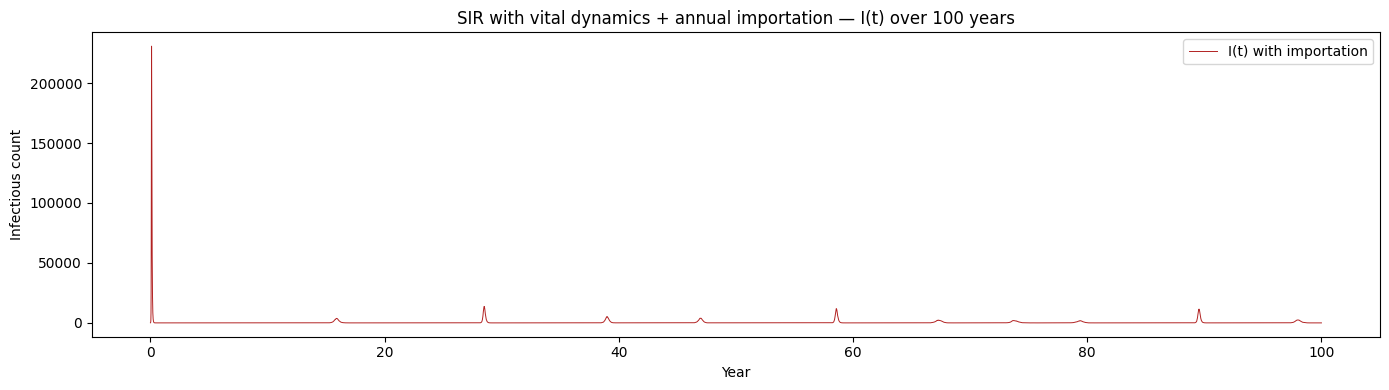

In [4]:
# --- Plot I(t) over 100 years ---
t_years = np.arange(nticks + 1) / 365

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t_years, I_ts, color="firebrick", linewidth=0.7, label="I(t) with importation")
ax.set_xlabel("Year")
ax.set_ylabel("Infectious count")
ax.set_title("SIR with vital dynamics + annual importation — I(t) over 100 years")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# --- Theoretical natural period ---
# Endemic equilibrium values
N_star  = N_ts.mean()   # use observed mean N as reference
I_star  = r_mortality_val * (beta_val - gamma) / (beta_val * gamma) * N_star

# Angular frequency of damped oscillations around equilibrium
omega   = np.sqrt(beta_val * I_star / N_star - r_mortality_val)
T_days  = 2 * np.pi / omega
T_years = T_days / 365

print(f"Endemic I*       : {I_star:,.1f}")
print(f"ω                : {omega:.6f} rad/day")
print(f"Theoretical T    : {T_days:.1f} days  =  {T_years:.2f} years")

Endemic I*       : 219.2
ω                : 0.012821 rad/day
Theoretical T    : 490.1 days  =  1.34 years


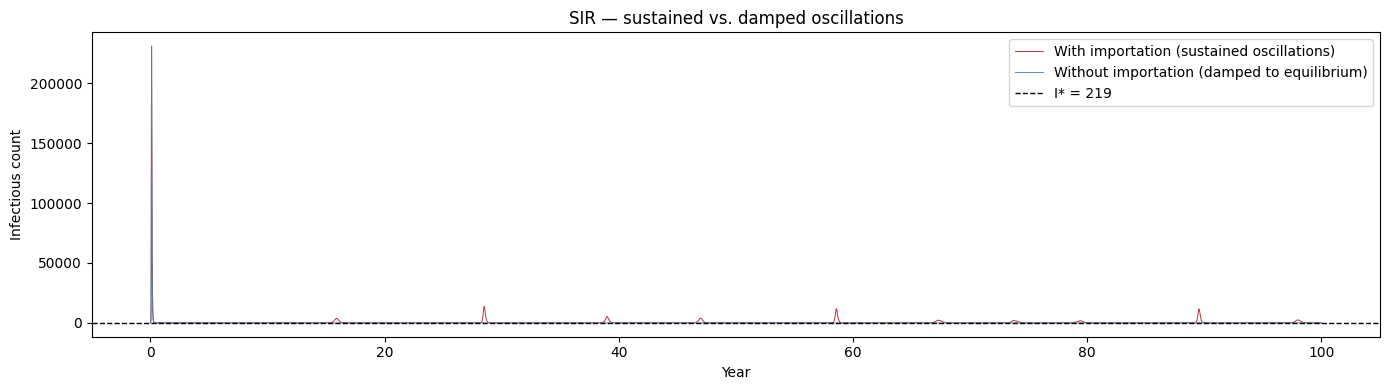

In [6]:
# --- Run second model WITHOUT importation ---
scenario2 = grid(M=1, N=1)
scenario2["S"] = N - I0
scenario2["I"] = I0
scenario2["R"] = 0

params2  = PropertySet({"nticks": nticks})
model2   = Model(scenario2, params2)

betas2        = ValuesMap.from_scalar(beta_val, nticks, n_nodes)
r_recoveries2 = ValuesMap.from_scalar(gamma,    nticks, n_nodes)
ndm2 = NonDiseaseMortality(model2, r_mortality=r_mortality_val)
cpb2 = ConstantPopBirths(model2)

model2.components = [
    SIR.Susceptible(model2),
    SIR.Infectious(model2, r_recovery=r_recoveries2),
    SIR.Recovered(model2),
    ndm2,
    cpb2,
    SIR.Transmission(model2, beta=betas2),
]

model2.run()
I_ts2 = model2.states.I[:, 0]

# --- Compare both on the same axes ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t_years, I_ts,  color="firebrick", linewidth=0.7, alpha=0.9,
        label="With importation (sustained oscillations)")
ax.plot(t_years, I_ts2, color="steelblue", linewidth=0.7, alpha=0.9,
        label="Without importation (damped to equilibrium)")
ax.axhline(I_star, color="black", linestyle="--", linewidth=1.0,
           label=f"I* = {I_star:,.0f}")
ax.set_xlabel("Year")
ax.set_ylabel("Infectious count")
ax.set_title("SIR — sustained vs. damped oscillations")
ax.legend()
plt.tight_layout()
plt.show()